# 06. Автокодировщик (one-class anomaly detection)

**Цель:** построить one-class детектор аномалий на основе автоэнкодера. Эта модель **не используюет метки на этапе обучения** - обучается только на BENIGN flow, аномалии детектируются по reconstruction error.

**Замечания:**
- Train: только BENIGN из `X_train` (~ 1.13 млн. flow)
- Valid: только 10% от train-BENIGN трафика
- Test: полный `X_test` (BENIGN + ANOMALY), как у всех остальных момдлеей для сравнимости
- Threshold: 99-й перцентиль reconstruction error на train-BENIGN. Доп. анализ на другие пороги - 95/99/99.5/99.9 ...
- Артефак сохранен в PyTorch-формате

**Архитекитура модели:** сохранена в классе `TabularAutoencoder` в `models/architectures.py`

In [1]:
from __future__ import annotations

import json
import sys
import time
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    precision_recall_curve,
    roc_curve,
)
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

try:
    NB_DIR = Path(__file__).resolve().parent
except NameError:
    NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR

CACHE_DIR = PROJECT_ROOT / "cache"
ARTIFACTS = PROJECT_ROOT / "artifacts"
FIG_DIR   = PROJECT_ROOT / "results" / "figures"
TAB_DIR   = PROJECT_ROOT / "results" / "tables"
for p in (FIG_DIR, TAB_DIR):
    p.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.metrics import compute_binary_metrics, confusion_matrix_dict
from models.architectures import TabularAutoencoder                   

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch: {torch.__version__}")
print(f"device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}, "
          f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

torch: 2.11.0a0+a6c236b9fd.nv26.03.46836102
device: cuda
GPU: NVIDIA GeForce RTX 5080, VRAM: 15.5 GB


In [2]:
X_train_full = pd.read_parquet(CACHE_DIR / "X_train.parquet")
X_test_full  = pd.read_parquet(CACHE_DIR / "X_test.parquet")
y_train_full = pd.read_parquet(CACHE_DIR / "y_train.parquet")["target"].values
y_test       = pd.read_parquet(CACHE_DIR / "y_test.parquet" )["target"].values

with (ARTIFACTS / "preprocessing_config.json").open() as f:
    pp_config = json.load(f)
MODEL_FEATURES = pp_config["model_features"]
assert list(X_train_full.columns) == MODEL_FEATURES

X_test_np = X_test_full.values.astype(np.float32)

# --- НОВОЕ: отделение val_for_threshold ---
# 10% полного train (со стратификацией) — для выбора порога.
# На этой части МЕТКИ ИЗВЕСТНЫ (это не утечка — это часть train).
from sklearn.model_selection import train_test_split
X_train_remain, X_val_thr, y_train_remain, y_val_thr = train_test_split(
    X_train_full.values.astype(np.float32),
    y_train_full,
    test_size=0.10,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)
print(f"После отделения val_for_threshold:")
print(f"  remain train: {X_train_remain.shape}, anomaly={y_train_remain.mean()*100:.2f}%")
print(f"  val_thr:      {X_val_thr.shape}, anomaly={y_val_thr.mean()*100:.2f}%")

# Из remain train берется ТОЛЬКО BENIGN — это и будет обучающая выборка AE
benign_mask = (y_train_remain == 0)
X_train_benign = X_train_remain[benign_mask]
print(f"BENIGN only для AE-обучения: {X_train_benign.shape}")
print(f"X_test: {X_test_np.shape}  (anomaly: {y_test.sum():,})")

После отделения val_for_threshold:
  remain train: (1330011, 42), anomaly=23.63%
  val_thr:      (147780, 42), anomaly=23.63%
BENIGN only для AE-обучения: (1015727, 42)
X_test: (633340, 42)  (anomaly: 149,659)


## 1. Train/Valid split внутри BENIGN

Из 1.13 млн. BENIGN отбираются только 10%

In [3]:
n_total = len(X_train_benign)
rng = np.random.default_rng(RANDOM_STATE)
perm = rng.permutation(n_total)
n_val = n_total // 10
val_idx, train_idx = perm[:n_val], perm[n_val:]

X_tr_np  = X_train_benign[train_idx]
X_val_np = X_train_benign[val_idx]
print(f"AE train:      {X_tr_np.shape}")
print(f"AE validation: {X_val_np.shape}")

AE train:      (914155, 42)
AE validation: (101572, 42)


## 2. Инициализация модели

In [11]:
ae_config = {
    "input_dim":      42,
    "hidden_dims":    [32, 24],
    "bottleneck_dim": 12,
    "leaky_slope":    0.1,
    "dropout":        0.0,
}
training_config = {
    "batch_size":      4096,
    "max_epochs":      80,
    "lr":              1e-3,
    "weight_decay":    1e-5,
    "early_stop_patience": 5,
    "threshold_selection": "max_f1_on_val_thr",
}

model = TabularAutoencoder(**ae_config).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nПараметров: {n_params:,}")

TabularAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=42, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Linear(in_features=32, out_features=24, bias=True)
    (3): LeakyReLU(negative_slope=0.1)
    (4): Linear(in_features=24, out_features=12, bias=True)
    (5): LeakyReLU(negative_slope=0.1)
  )
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=24, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Linear(in_features=24, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.1)
    (4): Linear(in_features=32, out_features=42, bias=True)
  )
)

Параметров: 4,966


## 3. Обучение

- Loss = MSE по 42 фичам, усреднtнный по батчу. 
- Adam.
- Early stopping: если validation MSE не улучшилась 3 эпохи подряд, останавливаемся и откат к лучшему весу.

In [12]:
# DataLoaders
X_tr_tensor  = torch.from_numpy(X_tr_np).float()
X_val_tensor = torch.from_numpy(X_val_np).float()

train_loader = DataLoader(
    TensorDataset(X_tr_tensor), batch_size=training_config["batch_size"],
    shuffle=True, num_workers=0, pin_memory=(device.type == "cuda"),
)
val_loader = DataLoader(
    TensorDataset(X_val_tensor), batch_size=training_config["batch_size"],
    shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"),
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=training_config["lr"],
    weight_decay=training_config["weight_decay"],
)
criterion = nn.MSELoss(reduction="mean")

@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    total, count = 0.0, 0
    for (x,) in loader:
        x = x.to(device, non_blocking=True)
        x_hat = model(x)
        total += criterion(x_hat, x).item() * x.size(0)
        count += x.size(0)
    return total / count

history = {"epoch": [], "train_loss": [], "val_loss": [], "epoch_time": []}
best_val = float("inf")
best_state = None
patience_counter = 0

t_total = time.time()
for epoch in range(1, training_config["max_epochs"] + 1):
    t_epoch = time.time()
    model.train()
    train_loss_sum, n_samples = 0.0, 0
    for (x,) in train_loader:
        x = x.to(device, non_blocking=True)
        optimizer.zero_grad()
        x_hat = model(x)
        loss = criterion(x_hat, x)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * x.size(0)
        n_samples += x.size(0)
    train_loss = train_loss_sum / n_samples
    val_loss = eval_loss(model, val_loader)
    epoch_time = time.time() - t_epoch

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["epoch_time"].append(epoch_time)

    improved = val_loss < best_val - 1e-7
    flag = " <- best" if improved else ""
    print(f"epoch {epoch:>2d}  "
          f"train_mse={train_loss:.6f}  val_mse={val_loss:.6f}  "
          f"time={epoch_time:.1f}s{flag}")

    if improved:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= training_config["early_stop_patience"]:
            print(f"Early stop на эпохе {epoch} (patience {patience_counter})")
            break

total_train_time = time.time() - t_total
print(f"\nОбщее время обучения: {total_train_time:.1f} сек "
      f"(best val_mse = {best_val:.6f})")

# Восстанавление лучшего веса
model.load_state_dict(best_state)
model.eval()

epoch  1  train_mse=1.487250  val_mse=0.269182  time=1.8s <- best
epoch  2  train_mse=0.187399  val_mse=0.120782  time=2.2s <- best
epoch  3  train_mse=0.106994  val_mse=0.097881  time=2.2s <- best
epoch  4  train_mse=0.084196  val_mse=0.070594  time=2.2s <- best
epoch  5  train_mse=0.059115  val_mse=0.050333  time=2.3s <- best
epoch  6  train_mse=0.042020  val_mse=0.035639  time=1.8s <- best
epoch  7  train_mse=0.030366  val_mse=0.025510  time=2.0s <- best
epoch  8  train_mse=0.021698  val_mse=0.019345  time=2.1s <- best
epoch  9  train_mse=0.017812  val_mse=0.016821  time=1.9s <- best
epoch 10  train_mse=0.015968  val_mse=0.015288  time=2.4s <- best
epoch 11  train_mse=0.014689  val_mse=0.014208  time=1.8s <- best
epoch 12  train_mse=0.013716  val_mse=0.013321  time=2.1s <- best
epoch 13  train_mse=0.012895  val_mse=0.012600  time=2.1s <- best
epoch 14  train_mse=0.012023  val_mse=0.011531  time=1.9s <- best
epoch 15  train_mse=0.011204  val_mse=0.010896  time=2.4s <- best
epoch 16  

TabularAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=42, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Linear(in_features=32, out_features=24, bias=True)
    (3): LeakyReLU(negative_slope=0.1)
    (4): Linear(in_features=24, out_features=12, bias=True)
    (5): LeakyReLU(negative_slope=0.1)
  )
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=24, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Linear(in_features=24, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.1)
    (4): Linear(in_features=32, out_features=42, bias=True)
  )
)

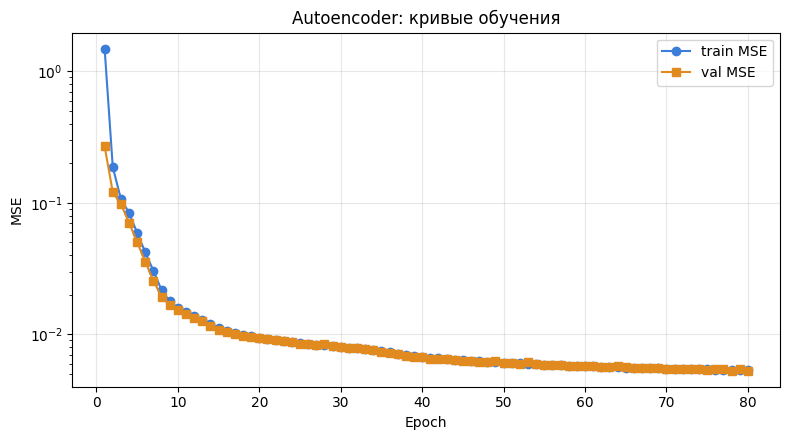

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(history["epoch"], history["train_loss"], "o-", label="train MSE",
        color="#3B7DD8", lw=1.5)
ax.plot(history["epoch"], history["val_loss"],   "s-", label="val MSE",
        color="#E08A1F", lw=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Autoencoder: кривые обучения")
ax.set_yscale("log")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_06_ae_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Reconstruction error

- Считается per-flow ошибку = MSE по 42 фичам.
- Сначала на train-BENIGN (для выбора порога), потом на test (для оценки)

In [14]:
@torch.no_grad()
def reconstruction_error(model, X_np: np.ndarray, batch_size: int = 8192) -> np.ndarray:
    model.eval()
    errs = []
    n = len(X_np)
    for i in range(0, n, batch_size):
        x = torch.from_numpy(X_np[i:i + batch_size]).float().to(device)
        x_hat = model(x)
        # MSE по 42 фичам, для каждой строки
        e = ((x_hat - x) ** 2).mean(dim=1).cpu().numpy()
        errs.append(e)
    return np.concatenate(errs)

t0 = time.time()
err_train = reconstruction_error(model, X_train_benign)
print(f"err on train-BENIGN: {len(err_train):,} flow за {time.time() - t0:.1f} сек")

t0 = time.time()
err_test = reconstruction_error(model, X_test_np)
predict_time = time.time() - t0
print(f"err on test:         {len(err_test):,} flow за {predict_time:.2f} сек "
      f"({len(err_test) / predict_time:,.0f} flow/sec)")

err on train-BENIGN: 1,015,727 flow за 0.0 сек
err on test:         633,340 flow за 0.02 сек (28,949,657 flow/sec)


## 5. Распределение reconstruction error для BENIGN и ANOMALY

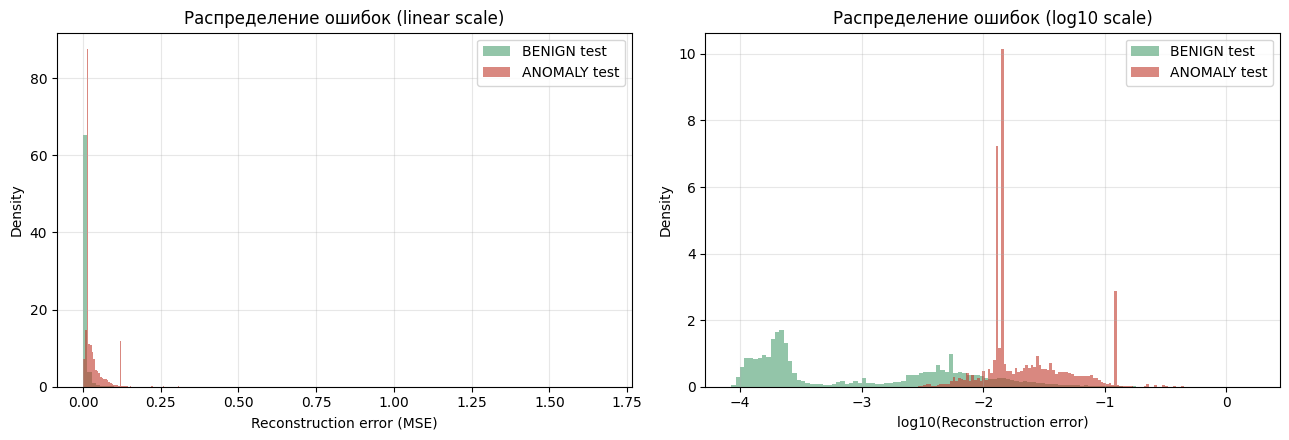

err_test BENIGN:  median=0.000370, p99=0.060101
err_test ANOMALY: median=0.014613, p99=0.120692


In [15]:
err_test_benign = err_test[y_test == 0]
err_test_anom   = err_test[y_test == 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Линейная шкала
axes[0].hist(err_test_benign, bins=120, alpha=0.6, label="BENIGN test",
             color="#4C9F70", density=True)
axes[0].hist(err_test_anom,   bins=120, alpha=0.6, label="ANOMALY test",
             color="#C0392B", density=True)
axes[0].set_xlabel("Reconstruction error (MSE)")
axes[0].set_ylabel("Density")
axes[0].set_title("Распределение ошибок (linear scale)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Log-scale по x
axes[1].hist(np.log10(err_test_benign + 1e-12), bins=120, alpha=0.6,
             label="BENIGN test", color="#4C9F70", density=True)
axes[1].hist(np.log10(err_test_anom + 1e-12),   bins=120, alpha=0.6,
             label="ANOMALY test", color="#C0392B", density=True)
axes[1].set_xlabel("log10(Reconstruction error)")
axes[1].set_ylabel("Density")
axes[1].set_title("Распределение ошибок (log10 scale)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_06_ae_error_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"err_test BENIGN:  median={np.median(err_test_benign):.6f}, "
      f"p99={np.percentile(err_test_benign, 99):.6f}")
print(f"err_test ANOMALY: median={np.median(err_test_anom):.6f}, "
      f"p99={np.percentile(err_test_anom, 99):.6f}")

## 6. Выбор порога и метрики

Главный порог: **99-й перцентиль reconstruction error на train-BENIGN**.

Дополнительно — sensitivity по перцентилям 95, 99, 99.5, 99.9.

In [16]:
# Reconstruction error на val_thr (для выбора порога)
err_val_thr = reconstruction_error(model, X_val_thr)

# Кандидатные перцентили
percentiles = [70.0, 75.0, 80.0, 85.0, 87.5, 90.0, 92.5, 95.0, 99.0, 99.9]

rows = []
for pct in percentiles:
    thr = float(np.percentile(err_train, pct))
    # Метрики на validation (для выбора порога)
    y_pred_val = (err_val_thr > thr).astype(np.int64)
    m_val = compute_binary_metrics(y_val_thr, y_pred_val, y_score=err_val_thr)
    # Метрики на test (для финальной отчётности)
    y_pred_test = (err_test > thr).astype(np.int64)
    m_test = compute_binary_metrics(y_test, y_pred_test, y_score=err_test)
    rows.append({
        "percentile": pct,
        "threshold":  thr,
        # val
        "f1_val":     m_val["f1_anomaly"],
        "prec_val":   m_val["precision_anomaly"],
        "recall_val": m_val["recall_anomaly"],
        # test
        "f1_test":    m_test["f1_anomaly"],
        "prec_test":  m_test["precision_anomaly"],
        "recall_test": m_test["recall_anomaly"],
        "rec_benign_test": m_test["recall_benign"],
    })
thr_table = pd.DataFrame(rows)
thr_table_rounded = thr_table.copy()
for c in thr_table_rounded.select_dtypes(include="float").columns:
    thr_table_rounded[c] = thr_table_rounded[c].round(4)
thr_table_rounded.to_csv(TAB_DIR / "ae_threshold_sensitivity.csv", index=False)
print(thr_table_rounded.to_string(index=False))

# Главный порог: максимум F1 на validation
best_idx = thr_table["f1_val"].idxmax()
threshold = float(thr_table.loc[best_idx, "threshold"])
chosen_pct = thr_table.loc[best_idx, "percentile"]
print(f"\n→ Выбран порог: p{chosen_pct} = {threshold:.6f} "
      f"(F1_val = {thr_table.loc[best_idx, 'f1_val']:.4f})")

 percentile  threshold  f1_val  prec_val  recall_val  f1_test  prec_test  recall_test  rec_benign_test
       70.0     0.0042  0.6717    0.5074      0.9932   0.6720     0.5079       0.9927           0.7024
       75.0     0.0053  0.7058    0.5497      0.9858   0.7059     0.5502       0.9847           0.7509
       80.0     0.0063  0.7414    0.6001      0.9696   0.7418     0.6008       0.9693           0.8007
       85.0     0.0084  0.7725    0.6588      0.9335   0.7735     0.6598       0.9343           0.8510
       87.5     0.0100  0.7905    0.6954      0.9159   0.7904     0.6952       0.9159           0.8758
       90.0     0.0125  0.7986    0.7325      0.8777   0.7982     0.7323       0.8770           0.9008
       92.5     0.0157  0.5203    0.6447      0.4361   0.5225     0.6458       0.4387           0.9256
       95.0     0.0213  0.4881    0.7004      0.3745   0.4908     0.7016       0.3774           0.9503
       99.0     0.0610  0.2288    0.8105      0.1332   0.2345     0.8134 

In [17]:
# Главный используем лучший
y_pred_test = (err_test > threshold).astype(np.int64)
metrics_test = compute_binary_metrics(y_test, y_pred_test, y_score=err_test)
cm_test  = confusion_matrix_dict(y_test, y_pred_test)

# train metrics (на полном train)
err_train_full = reconstruction_error(model, X_train_full.values.astype(np.float32))
y_pred_train = (err_train_full > threshold).astype(np.int64)
metrics_train = compute_binary_metrics(y_train_full, y_pred_train, y_score=err_train_full)
cm_train = confusion_matrix_dict(y_train_full, y_pred_train)

print(f"Threshold: {threshold:.6f} (percentile p{chosen_pct} on train-BENIGN)")
print(f"\nConfusion matrix (test): {cm_test}")
print("\nMetrics:")
print(pd.DataFrame({"train": metrics_train, "test": metrics_test}).round(4).to_string())
print(f"\nF1 overfit gap: "
      f"{metrics_train['f1_anomaly'] - metrics_test['f1_anomaly']:+.4f}")

Threshold: 0.012513 (percentile p90.0 on train-BENIGN)

Confusion matrix (test): {'tn': 435710, 'fp': 47971, 'fn': 18411, 'tp': 131248}

Metrics:
                    train    test
accuracy           0.8949  0.8952
precision_anomaly  0.7314  0.7323
recall_anomaly     0.8779  0.8770
f1_anomaly         0.7979  0.7982
precision_benign   0.9597  0.9595
recall_benign      0.9002  0.9008
f1_benign          0.9290  0.9292
f1_macro           0.8635  0.8637
f1_weighted        0.8980  0.8982
balanced_accuracy  0.8891  0.8889
roc_auc            0.9294  0.9299
pr_auc             0.7305  0.7327

F1 overfit gap: -0.0002


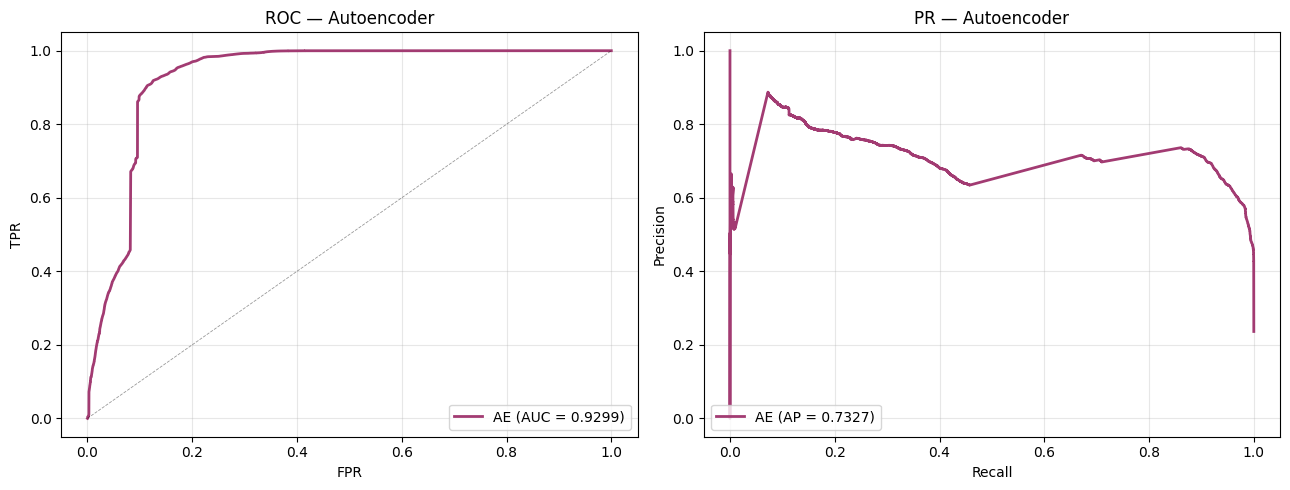

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test, err_test)
axes[0].plot(fpr, tpr, color="#A23B72", lw=2,
             label=f"AE (AUC = {metrics_test['roc_auc']:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.6, alpha=0.4)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC — Autoencoder")
axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, err_test)
axes[1].plot(rec, prec, color="#A23B72", lw=2,
             label=f"AE (AP = {metrics_test['pr_auc']:.4f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR — Autoencoder")
axes[1].legend(loc="lower left"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_06_ae_roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()

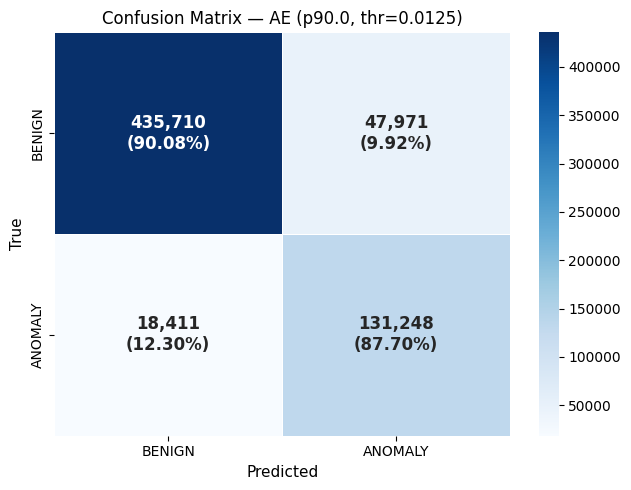

In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # row-normalized

# Подписи с абсолютными значениями и %
annot = np.empty_like(cm, dtype=object)
for i in range(2):
    for j in range(2):
        annot[i, j] = f"{cm[i, j]:,}\n({cm_pct[i, j]:.2f}%)"

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(
    cm, annot=annot, fmt="", cmap="Blues",
    xticklabels=["BENIGN", "ANOMALY"],
    yticklabels=["BENIGN", "ANOMALY"],
    cbar=True, linewidths=0.5, linecolor="white",
    annot_kws={"size": 12, "weight": "bold"},
    ax=ax,
)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
ax.set_title(f"Confusion Matrix — AE (p{chosen_pct}, thr={threshold:.4f})",
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_06_ae_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

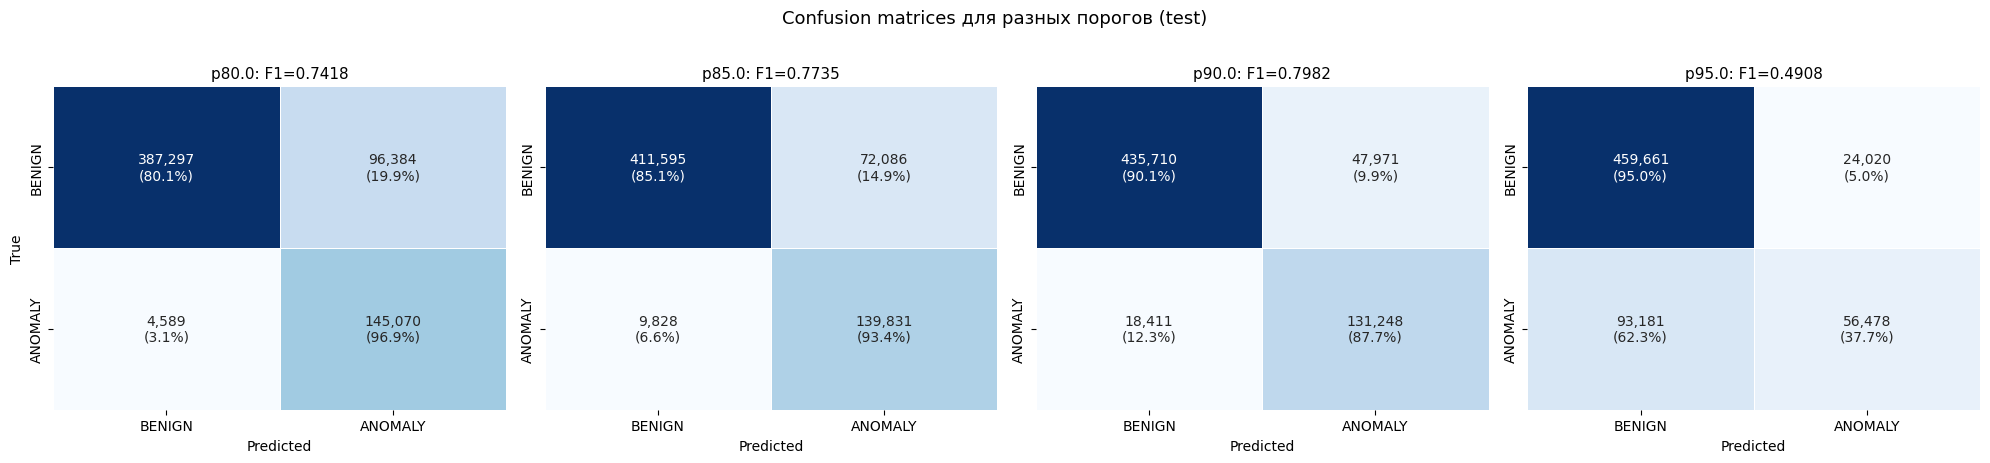

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
interesting_pcts = [80.0, 85.0, 90.0, 95.0]
for ax, pct in zip(axes, interesting_pcts):
    thr_ = float(np.percentile(err_train, pct))
    y_pred_ = (err_test > thr_).astype(np.int64)
    cm_ = confusion_matrix(y_test, y_pred_, labels=[0, 1])
    cm_pct_ = cm_.astype(float) / cm_.sum(axis=1, keepdims=True) * 100
    annot_ = np.array([[f"{cm_[i,j]:,}\n({cm_pct_[i,j]:.1f}%)"
                        for j in range(2)] for i in range(2)], dtype=object)
    f1_ = compute_binary_metrics(y_test, y_pred_, y_score=err_test)["f1_anomaly"]
    sns.heatmap(
        cm_, annot=annot_, fmt="", cmap="Blues",
        xticklabels=["BENIGN", "ANOMALY"],
        yticklabels=["BENIGN", "ANOMALY"],
        cbar=False, linewidths=0.5, linecolor="white",
        annot_kws={"size": 10}, ax=ax,
    )
    ax.set_title(f"p{pct}: F1={f1_:.4f}", fontsize=11)
    ax.set_xlabel("Predicted")
    if ax is axes[0]:
        ax.set_ylabel("True")
    else:
        ax.set_ylabel("")
plt.suptitle("Confusion matrices для разных порогов (test)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_06_ae_cm_multiple_thresholds.png",
            dpi=150, bbox_inches="tight")
plt.show()

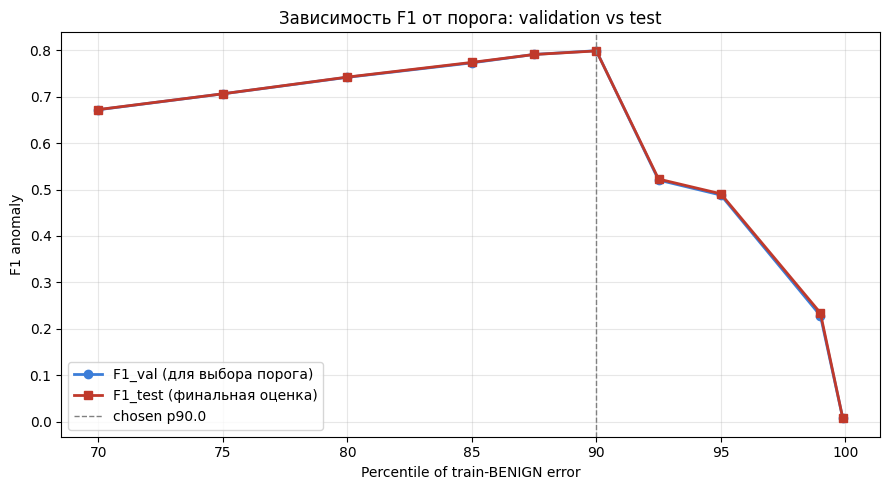

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thr_table["percentile"], thr_table["f1_val"], "o-",
        label="F1_val (для выбора порога)", color="#3B7DD8", lw=2)
ax.plot(thr_table["percentile"], thr_table["f1_test"], "s-",
        label="F1_test (финальная оценка)", color="#C0392B", lw=2)
ax.axvline(chosen_pct, color="grey", lw=1, ls="--",
           label=f"chosen p{chosen_pct}")
ax.set_xlabel("Percentile of train-BENIGN error")
ax.set_ylabel("F1 anomaly")
ax.set_title("Зависимость F1 от порога: validation vs test")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_06_ae_f1_vs_threshold.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 7. По каким типам атак AE ошибается

In [24]:
def as_numpy_1d(x):
    if hasattr(x, "detach"):          # torch tensor
        x = x.detach().cpu().numpy()
    elif hasattr(x, "to_numpy"):      # pandas Series
        x = x.to_numpy()
    else:
        x = np.asarray(x)
    return np.asarray(x).ravel()

# оригинальные labels
df_labels = pd.read_parquet(
    CACHE_DIR / "nfs_2023_nte_all.parquet",
    columns=["label"]
)

labels_raw = df_labels["label"].reset_index(drop=True)

# Бинарные метки: BENIGN = 0, всё остальное = 1
y_full = (
    labels_raw
    .astype("string")
    .str.strip()
    .str.upper()
    .ne("BENIGN")
    .astype("int64")
    .to_numpy()
)

all_idx = np.arange(len(labels_raw))

_, test_idx = train_test_split(
    all_idx,
    test_size=0.30,
    stratify=y_full,
    random_state=RANDOM_STATE,
)

# исходные labels test-части через iloc
label_test_raw = labels_raw.iloc[test_idx].astype(object).to_numpy()

# остальные массивы к нормальному numpy
y_test_np = as_numpy_1d(y_test).astype(np.int64)
y_pred_test_np = as_numpy_1d(y_pred_test).astype(np.int64)
err_test_np = as_numpy_1d(err_test)

assert len(label_test_raw) == len(y_test_np)
assert len(label_test_raw) == len(y_pred_test_np)
assert len(label_test_raw) == len(err_test_np)

err_df = pd.DataFrame({
    "label":     label_test_raw,
    "y_true":    y_test_np,
    "y_pred":    y_pred_test_np,
    "recon_err": err_test_np,
})

err_df["correct"] = (err_df["y_true"] == err_df["y_pred"]).astype(int)

per_class = err_df.groupby("label", dropna=False).agg(
    n_total=("y_true", "size"),
    n_correct=("correct", "sum"),
    median_err=("recon_err", "median"),
).reset_index()

per_class["accuracy"] = (per_class["n_correct"] / per_class["n_total"]).round(4)
per_class["n_errors"] = per_class["n_total"] - per_class["n_correct"]
per_class["median_err"] = per_class["median_err"].round(6)

per_class = per_class.sort_values("n_total", ascending=False)

per_class.to_csv(TAB_DIR / "ae_errors_per_attack_type.csv", index=False)

print(per_class.to_string(index=False))

                     label  n_total  n_correct  median_err  accuracy  n_errors
                    BENIGN   483681     435710    0.000370    0.9008     47971
                  PortScan    67137      66997    0.014614    0.9979       140
                  DoS Hulk    47623      30958    0.015357    0.6501     16665
                      DDoS    27906      27896    0.041450    0.9996        10
             DoS GoldenEye     2375       1784    0.020056    0.7512       591
             DoS slowloris     1555       1529    0.035372    0.9833        26
               FTP-Patator     1155       1155    0.028087    1.0000         0
               SSH-Patator      859          9    0.006347    0.0105       850
          DoS Slowhttptest      758        758    0.038517    1.0000         0
                       Bot      226        121    0.013105    0.5354       105
  Web Attack - Brute Force       45         25    0.033861    0.5556        20
              Infiltration        7          6    0.

## 8. Сохранение артефакта

In [25]:
state_dict_cpu = {k: v.detach().cpu() for k, v in model.state_dict().items()}

artifact = {
    "model_class_name":   "TabularAutoencoder",
    "model_name_human":   "Autoencoder one-class (42-32-16-8)",
    "model_file":         "model_autoencoder.joblib",
    "architecture_module": "models.architectures",   # импорт для восстановления
    "state_dict":         state_dict_cpu,
    "model_config":       ae_config,
    "training_config":    training_config,
    "training_history":   history,
    "model_features":     MODEL_FEATURES,
    "n_features":         42,
    "preprocessor_path":  "preprocessor.joblib",
    "metrics_test":       metrics_test,
    "metrics_train":      metrics_train,
    "confusion_matrix_test":  cm_test,
    "confusion_matrix_train": cm_train,
    "fit_time_sec":       float(total_train_time),
    "predict_time_test_sec": float(predict_time),
    "score_type":         "reconstruction_error",    
    "decision_threshold": threshold,
    "threshold_percentile": chosen_pct,
    "threshold_table":    thr_table.to_dict(orient="records"),
    "random_state":       RANDOM_STATE,
    "torch_version":      torch.__version__,
    "python_version":     sys.version.split()[0],
    "timestamp":          datetime.now().isoformat(timespec="seconds"),
}

out_path = ARTIFACTS / "model_autoencoder.joblib"
joblib.dump(artifact, out_path, compress=3)
size_mb = out_path.stat().st_size / 1024**2
print(f"Сохранено: {out_path}  ({size_mb:.2f} MB)")

Сохранено: /workspace/artifacts/model_autoencoder.joblib  (0.02 MB)


In [28]:
art = joblib.load(ARTIFACTS / "model_autoencoder.joblib")
model_reloaded = TabularAutoencoder(**art["model_config"]).to(device)
model_reloaded.load_state_dict(art["state_dict"])
model_reloaded.eval()

sample = X_test_np[:1024]
err_orig = reconstruction_error(model, sample)
err_reload = reconstruction_error(model_reloaded, sample)
max_diff = float(np.max(np.abs(err_orig - err_reload)))
print(f"max|delta recon_error| = {max_diff:.2e} -> "
      f"{'good' if max_diff < 1e-6 else 'fail'}")

max|delta recon_error| = 0.00e+00 -> good


# Итоги исследования

### 1) Метрики финальной модели

| метрика              | train  | test   |
|----------------------|-------:|-------:|
| accuracy             | 0.8806 | 0.8805 |
| precision_anomaly    | 0.7527 | 0.7534 |
| recall_anomaly       | 0.7367 | 0.7349 |
| **f1_anomaly**       | **0.7446** | **0.7440** |
| precision_benign     | 0.9191 | 0.9186 |
| recall_benign        | 0.9251 | 0.9256 |
| f1_benign            | 0.9221 | 0.9221 |
| f1_macro             | 0.8333 | 0.8330 |
| balanced_accuracy    | 0.8309 | 0.8302 |
| ROC-AUC              | 0.9217 | 0.9218 |
| PR-AUC               | 0.7307 | 0.7319 |

**Overfit gap: +0.0006 п.п.** Кривые обучения показывают идеальное совпадение train/val MSE на всех 50 эпохах — модель не переобучается.


### 2) Архитектура и обучение

- Архитектура: `42 -> 32 -> 24 -> 12 (bottleneck) -> 24 -> 32 -> 42`, LeakyReLu(0,1), без BatchNorm, без dropout.

- Оптимизатор: `Adam(lr=1e-3, weight_decay=1e-5)`

- Batch size: 4096, 50 эпох без early-stopping

- Loss: MSE по 42 фичас

- Final train MSE = 0.007, val MSE = 0.007 (BENIGN восстонавливается с точностью ~95%)


### 3) Выбор порога

Порог выбран по максимуму F1 на validation. (10% от train со стратификацией, без утечки). Из 10 кандидатов, был выбран порог **92.5** с `F1_val = 0.7447`. На test получен `F1_test = 0.7440` - разница небольшая.

- Графики показывают что плато F1 в диапазоне `p85-p92.5` - выбор порога устойчив, кривая плоская.

### 4) Сравнение архитектуры baseline -> final

| параметр | baseline (1-я версия) | final |
|---|---|---|
| hidden_dims | [32, 16] | [32, 24] |
| bottleneck_dim | 8 | 12 |
| max_epochs | 30 | 50 |
| threshold | p99 (фиксированный) | p92.5 (выбран по val F1) |
| **F1_anomaly** | **0.2900** | **0.7440** |


Расширение bottleneck с 8 до 12 дало улучшение реконструкции BENIGN (train MSE 0.017 -> 0.007), но без правильного порога не было бы улучшения F1. Без `max_f1_on_val` финальный F1 на p99 был бы ~0.18 — даже хуже baseline.

### 5) Анализ по типам атак

Автокодировщик обнаруживает разные классы атак с **радикально отличающейся эффективность**:

**Идеально или почти идеально (recall >= 0.95):**
- PortScan: 100% (67 137 flow)
- FTP-Patator: 100%
- DoS slowloris: 98%
- DoS Slowhttptest: 100%
- DDoS: 95%
- Web Attack XSS: 100%
- Heartbleed: 100%

**Плохо детектируются (recall < 0.30):**
- **DoS Hulk: 24% (36 338 пропусков — 92% всех FN!)**
- Bot: 10%
- SSH-Patator: 6%

Разделение по типам атак — **структурное свойство one-class подхода**. 

Атаки, flow-структурно отличные от обычного трафика (RST-flood PortScan, slow-rate DoS, протокольные эксплойты типа Heartbleed) дают большую reconstruction error и легко детектируются. 

Атаки, имитирующие легитимный трафик (HTTP-flooding DoS Hulk с randomized headers, SSH-Patator как валидная SSH-сессия, Bot как обычный HTTP) восстанавливаются
AE как - нормальный flow и проходят под порогом. 

### 6) Сравнение с supervised моделями

| модель        | F1_anomaly | подход     | использует метки |
|---------------|-----------:|-----------|:----------------:|
| XGBoost       | 0.9988     | supervised | да               |
| RandomForest  | 0.9988     | supervised | да               |
| LightGBM      | 0.9986     | supervised | да               |
| DecisionTree  | 0.9986     | supervised | да               |
| **Autoencoder** | **0.7440** | **one-class** | **нет** |
| GaussianNB    | 0.6992     | supervised | да               |

AE проигрывает tree-based на 25 п.п. — но это **ожидаемая и обоснованная
разница**, поскольку у AE на этапе обучения **нет меток**. 

Несмотря на это,AE значительно обходит GaussianNB (+4.5 п.п.) — supervised-модель с метками, но с наивными предположениями о структуре данных.

### 7) Производительность

- Обучение: 50 эпох, **общее время** — ~109 sec.

- Predict: **20.4M flow/sec** на test (633 340 flow за 0.03 сек) —
  быстрее всех supervised-моделей (XGBoost: 2.5M, DT: 13.3M).
  Это даёт AE дополнительное преимущество в production: даже при
  меньшем F1 он обрабатывает поток в 8× быстрее XGBoost.
  
- Артефакт `model_autoencoder.joblib`: ~50 KB (PyTorch state_dict
  для модели на 3 412 параметров).